# Predicting Students' Exam Scores

**Dataset:** Student Performance Factors (`task1/StudentPerformanceFactors.csv`)

**Goal:** Build a series of regression models â€” from a simple single-variable linear baseline to
polynomial and multi-feature models â€” that predict the `Exam_Score`, and compare them fairly on
RÂ², MAE and RMSE.

**Tooling (task rules):** pandas, matplotlib, seaborn and scikit-learn only, all inside this notebook.


## 1. Load & First Look

We start by loading the CSV and getting a quick overview of the data before any modelling:
shape, data types, summary statistics and the first few rows. This tells us how big the data is,
which columns are numeric vs categorical, and whether anything looks odd (ranges, scales, obvious
missing values) before we dive into analysis.

In [3]:
# Check and install required libraries
import sys
import subprocess
import importlib

required_libraries = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn"
}

for library, package in required_libraries.items():
    try:
        importlib.import_module(library)
        print(f"✓ {package} is already installed")
    except ImportError:
        print(f"✗ {package} is not installed. Installing...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", package
        ])
        print(f"✓ {package} installed successfully")

print("\nAll required libraries are ready!")

✗ pandas is not installed. Installing...
✓ pandas installed successfully
✓ numpy is already installed
✗ matplotlib is not installed. Installing...
✓ matplotlib installed successfully
✗ seaborn is not installed. Installing...
✓ seaborn installed successfully
✗ scikit-learn is not installed. Installing...
✓ scikit-learn installed successfully

All required libraries are ready!


In [4]:
# Import every library used in this notebook.
import pandas as pd            # tabular data handling
import numpy as np             # numerical computing
import matplotlib.pyplot as plt  # basic plotting
import seaborn as sns          # statistical/beautiful plots
from sklearn.model_selection import train_test_split          # 80/20 split
from sklearn.linear_model import LinearRegression             # linear model
from sklearn.preprocessing import PolynomialFeatures          # polynomial expansion
from sklearn.pipeline import make_pipeline                    # transformer + model in one
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  # metrics

# Render plots directly inside the notebook.
%matplotlib inline
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [5]:
# Load the raw CSV file.
df = pd.read_csv('StudentPerformanceFactors.csv')

# The raw file ships with 3 extra columns (Parental_Involvement, Access_to_Resources,
# Extracurricular_Activities) that are outside the scope of this task, so we keep only
# the 17 columns listed in the brief.
cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
        'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality',
        'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
        'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']
df = df[cols]

# 1) Shape (rows, columns)
print('Shape:', df.shape)

# 2) Data types of every column
print('\n--- dtypes ---')
print(df.dtypes)

# 3) Summary statistics of numerical columns (count, mean, std, min, quartiles, max)
print('\n--- describe() ---')
print(df.describe())

# 4) Preview the first 5 rows.
print('\n--- head() ---')
print(df.head())

Shape: (6607, 17)

--- dtypes ---
Hours_Studied               int64
Attendance                  int64
Sleep_Hours                 int64
Previous_Scores             int64
Motivation_Level              str
Internet_Access               str
Tutoring_Sessions           int64
Family_Income                 str
Teacher_Quality               str
School_Type                   str
Peer_Influence                str
Physical_Activity           int64
Learning_Disabilities         str
Parental_Education_Level      str
Distance_from_Home            str
Gender                        str
Exam_Score                  int64
dtype: object

--- describe() ---
       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.00000

## 2. Exploratory Data Analysis (EDA)

Before modelling we explore the data visually. We check:
* the **distribution of the target** (`Exam_Score`) â€” is it normal-ish, skewed, are there outliers?
* the **distribution of `Hours_Studied`** â€” the single feature we will use for the baseline;
* the **relationship between `Hours_Studied` and `Exam_Score`** â€” is it linear?
* the **correlations among all numerical features** â€” do features move together? which one is
most correlated with the target?
* **boxplots of key categorical columns vs `Exam_Score`** â€” do group means differ?

This guides feature selection and tells us what modelling approach is sensible.

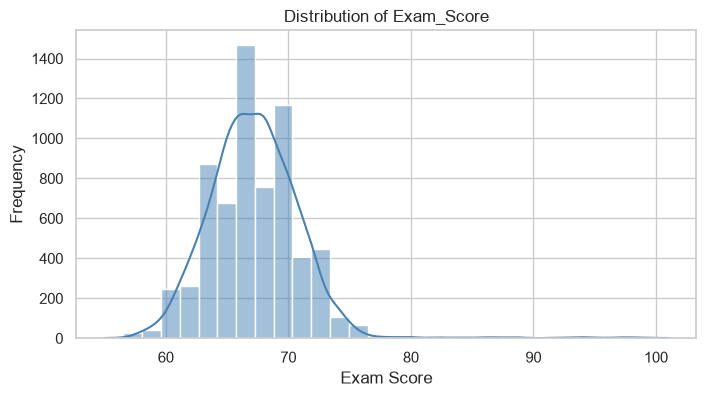

In [6]:
# Histogram + KDE of the target variable Exam_Score to see its distribution.
plt.figure(figsize=(8, 4))
sns.histplot(df['Exam_Score'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Exam_Score')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

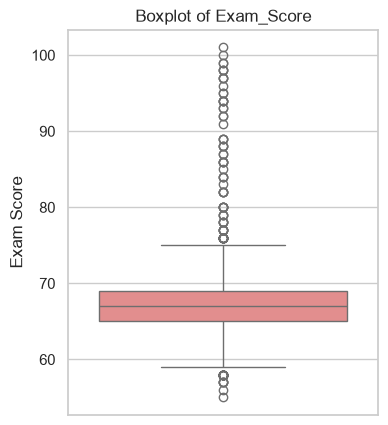

In [7]:
# Boxplot of Exam_Score to spot outliers and see spread/median.
plt.figure(figsize=(4, 5))
sns.boxplot(y=df['Exam_Score'], color='lightcoral')
plt.title('Boxplot of Exam_Score')
plt.ylabel('Exam Score')
plt.show()

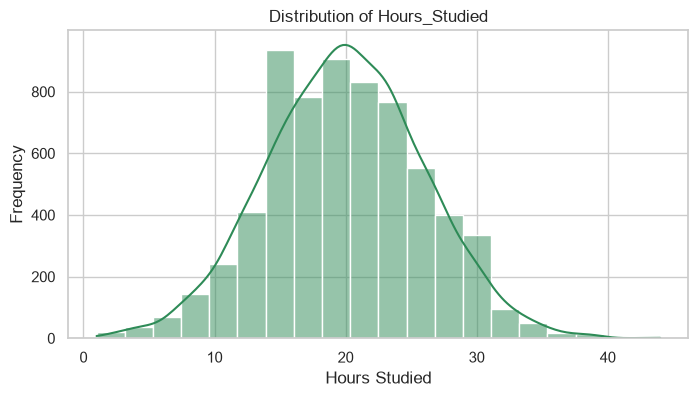

In [8]:
# Histogram of the baseline feature Hours_Studied.
plt.figure(figsize=(8, 4))
sns.histplot(df['Hours_Studied'], bins=20, kde=True, color='seagreen')
plt.title('Distribution of Hours_Studied')
plt.xlabel('Hours Studied')
plt.ylabel('Frequency')
plt.show()

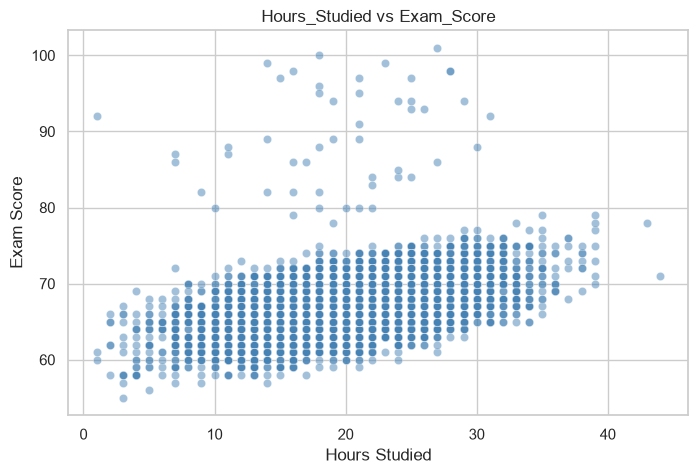

In [9]:
# Scatter plot: relationship between Hours_Studied and Exam_Score.
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, alpha=0.5, color='steelblue')
plt.title('Hours_Studied vs Exam_Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

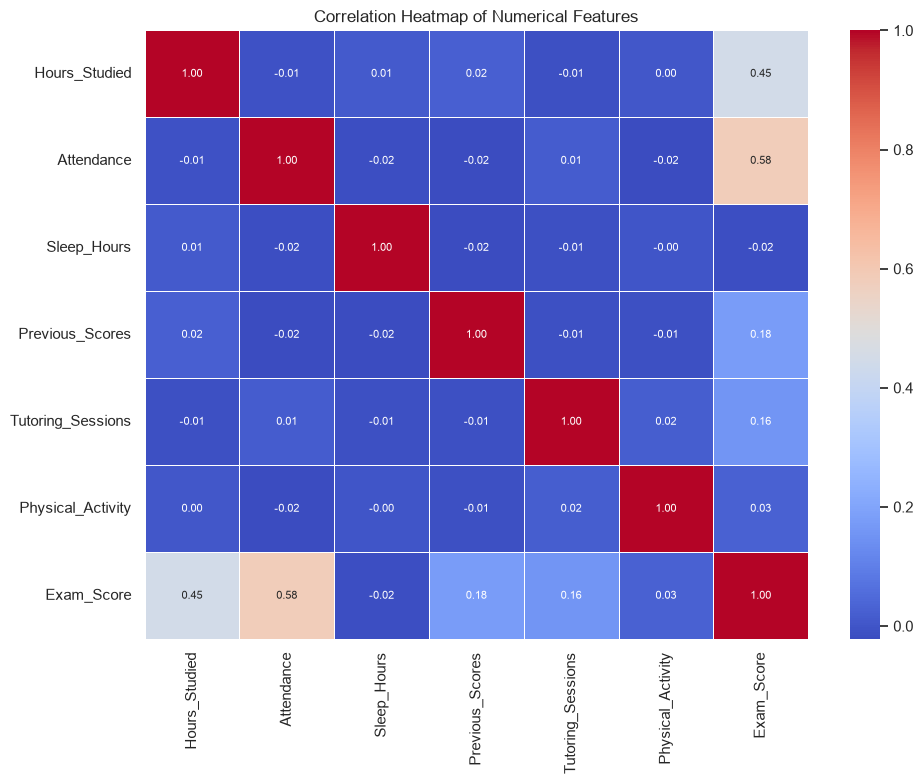

In [10]:
# Correlation heatmap of all numerical features (including the target).
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

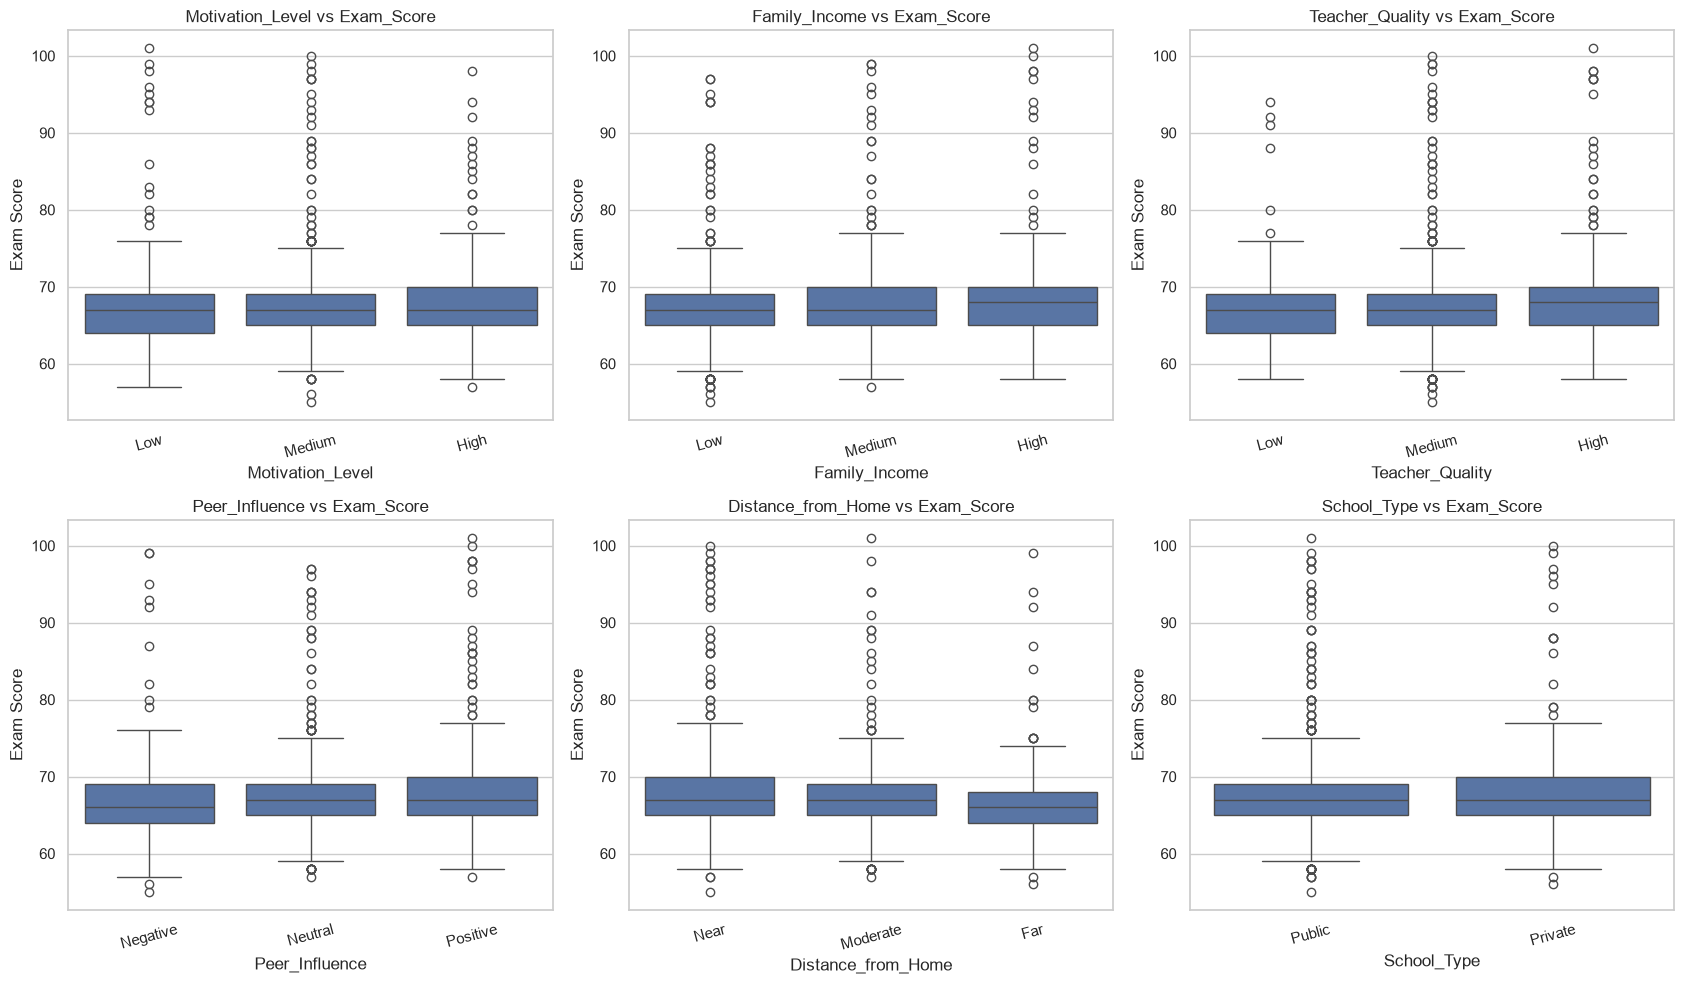

In [11]:
# Boxplots of key categorical columns vs Exam_Score to see whether the group distributions differ.
key_cats = ['Motivation_Level', 'Family_Income', 'Teacher_Quality', 'Peer_Influence',
            'Distance_from_Home', 'School_Type']
order_map = {'Motivation_Level': ['Low', 'Medium', 'High'],
             'Family_Income': ['Low', 'Medium', 'High'],
             'Teacher_Quality': ['Low', 'Medium', 'High'],
             'Peer_Influence': ['Negative', 'Neutral', 'Positive'],
             'Distance_from_Home': ['Near', 'Moderate', 'Far'],
             'School_Type': ['Public', 'Private']}

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, feat in zip(axes.flat, key_cats):
    # Ordered boxplots so the categories read naturally left->right.
    sns.boxplot(x=feat, y='Exam_Score', data=df, order=order_map[feat], ax=ax)
    ax.set_title(f'{feat} vs Exam_Score')
    ax.set_xlabel(feat)
    ax.set_ylabel('Exam Score')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 3. Data Cleaning

Raw datasets are rarely ready to model. In this step we:
* **handle missing values** (impute with the most frequent category);
* **drop duplicate rows** (if any);
* **fix data types** â€” make sure numeric columns really are numeric;
* **encode categorical columns** â€” models only understand numbers, so we map categories to integers
  (ordered maps for ordinal categories, 0/1 for binary ones);
* **flag and handle outliers** â€” the IQR rule applies to continuous features only (encoded
  0/1 columns would otherwise produce meaningless flags), and we clip their most extreme values
  while keeping legitimate high/low exam scores (the target).

In [12]:
# --- Missing values ---
print('Missing values per column:\n', df.isna().sum()[df.isna().sum() > 0])

# Missing values only occur in 3 categorical columns; fill them with the mode (= most frequent).
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    df[col] = df[col].fillna(df[col].mode()[0])

# --- Duplicates ---
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

# --- Fix data types: force the truly numeric columns to numeric, guard against bad parsing.
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
            'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Remaining missing values (total):', df.isna().sum().sum())
print('Shape after cleaning:', df.shape)

Missing values per column:
 Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64
Duplicate rows: 0
Remaining missing values (total): 0
Shape after cleaning: (6607, 17)


In [13]:
# --- Encode categorical columns ---
# Ordinal categories get increasing integers that respect their natural order.
ordinal_maps = {
    'Motivation_Level':        {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income':           {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality':         {'Low': 0, 'Medium': 1, 'High': 2},
    'Peer_Influence':          {'Negative': 0, 'Neutral': 1, 'Positive': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home':      {'Near': 0, 'Moderate': 1, 'Far': 2},
}
for col, mp in ordinal_maps.items():
    df[col] = df[col].map(mp)

# Binary categories are simply mapped to 0/1.
df['Internet_Access']       = df['Internet_Access'].map({'Yes': 1, 'No': 0})
df['Learning_Disabilities'] = df['Learning_Disabilities'].map({'Yes': 1, 'No': 0})
df['Gender']                = df['Gender'].map({'Male': 1, 'Female': 0})
df['School_Type']           = df['School_Type'].map({'Public': 1, 'Private': 0})

# Sanity check: everything should now be numeric.
print('dtypes after encoding:\n', df.dtypes)
print('\nhead after encoding:\n', df.head())

dtypes after encoding:
 Hours_Studied               int64
Attendance                  int64
Sleep_Hours                 int64
Previous_Scores             int64
Motivation_Level            int64
Internet_Access             int64
Tutoring_Sessions           int64
Family_Income               int64
Teacher_Quality             int64
School_Type                 int64
Peer_Influence              int64
Physical_Activity           int64
Learning_Disabilities       int64
Parental_Education_Level    int64
Distance_from_Home          int64
Gender                      int64
Exam_Score                  int64
dtype: object

head after encoding:
    Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Motivation_Level  \
0             23          84            7               73                 0   
1             19          64            8               59                 0   
2             24          98            7               91                 1   
3             29          89            8

In [14]:
# Define the sensible continuous columns: the IQR outlier rule is only meaningful
# for continuous measurements, NOT for the freshly encoded 0/1/2 categorical columns.
continuous_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
                   'Tutoring_Sessions', 'Physical_Activity']

# --- Flag outliers using the IQR rule ---
# Report counts for the continuous features plus the target Exam_Score.
flag_cols = continuous_cols + ['Exam_Score']
outlier_flags = {}
for col in flag_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_flags[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

print('Rows flagged as outliers per column (IQR rule):')
print(pd.Series(outlier_flags))

# --- Handle outliers: winsorize (clip) extreme *continuous feature* values to the IQR whiskers.
# We clip the features so a few extreme students cannot dominate the regression line,
# while we KEEP outliers in the target Exam_Score (scores are bounded 0-100 and are a
# legitimate part of the signal we want to predict). Encoded categorical columns are NOT
# clipped because their 0/1/2 values are already well-defined categories.
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    df[col] = df[col].clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)

# Re-check: continuous features no longer have outliers beyond the whiskers, target kept as-is.
outlier_flags_after = {}
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_flags_after[col] = int(((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum())
print('\nOutliers remaining in continuous features after clipping:\n',
      pd.Series(outlier_flags_after))

Rows flagged as outliers per column (IQR rule):
Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64

Outliers remaining in continuous features after clipping:
 Hours_Studied        0
Attendance           0
Sleep_Hours          0
Previous_Scores      0
Tutoring_Sessions    0
Physical_Activity    0
dtype: int64


## 4. Feature Selection

Following the brief, our **baseline** deliberately uses a **single feature: `Hours_Studied`**.
Starting with one feature gives us a simple, interpretable benchmark that the polynomial and
multi-feature models must beat â€” it also isolates exactly how much "study time" alone can explain
an exam score.

In [15]:
# The baseline feature matrix is just Hours_Studied; the target is always Exam_Score.
X_base = df[['Hours_Studied']]
y = df['Exam_Score']

print('X (features):', X_base.shape)
print('y (target):  ', y.shape)

X (features): (6607, 1)
y (target):   (6607,)


## 5. Train/Test Split

We split the data **80% train / 20% test** with `random_state=42` (reproducible). The model never
touches the test set until evaluation â€” this gives us an honest estimate of how it will perform
on unseen students. The same split is reused for every model so the comparison is fair.

In [16]:
# 80/20 stratified-free split with a fixed random seed so results are reproducible.
X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2,
                                                    random_state=42)

print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])

Train size: 5285
Test size:  1322


## 6. Baseline Model â€” Linear Regression on `Hours_Studied`

We fit a simple linear regression `Exam_Score = w * Hours_Studied + b`. Then we:
* predict on the held-out test set;
* plot the fitted regression line over the scatter of test points;
* plot **Actual vs Predicted** (points on the diagonal = perfect predictions);
* evaluate with **RÂ²**, **MAE** and **RMSE**.

In [17]:
# Train the baseline linear regression on Hours_Studied only.
model_base = LinearRegression()
model_base.fit(X_train, y_train)

# Predict on the test set.
y_pred_base = model_base.predict(X_test)

# Store the fitted line coefficients for plotting later.
b0 = model_base.intercept_
b1 = model_base.coef_[0]
print(f'Fitted line: Exam_Score = {b1:.3f} * Hours_Studied + {b0:.3f}')

# Evaluate with the three requested metrics.
def evaluate(y_true, y_pred):
    '''Return R2, MAE and RMSE for a set of predictions.'''
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse

r2_base, mae_base, rmse_base = evaluate(y_test, y_pred_base)
print(f'Baseline  R2  = {r2_base:.4f}')
print(f'Baseline  MAE = {mae_base:.4f}')
print(f'Baseline  RMSE= {rmse_base:.4f}')

Fitted line: Exam_Score = 0.287 * Hours_Studied + 61.482
Baseline  R2  = 0.2324
Baseline  MAE = 2.4460
Baseline  RMSE= 3.2940


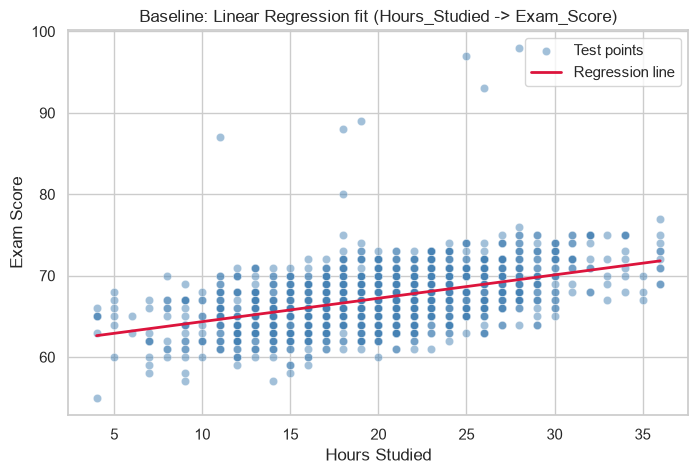

In [18]:
# Plot the fitted regression line over the test set scatter.
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_test['Hours_Studied'], y=y_test, alpha=0.5, color='steelblue',
                label='Test points')

# Draw the line over a dense grid of Hours_Studied values.
xs = np.linspace(X_test['Hours_Studied'].min(), X_test['Hours_Studied'].max(), 200)
plt.plot(xs, b1 * xs + b0, color='crimson', linewidth=2, label='Regression line')

plt.title('Baseline: Linear Regression fit (Hours_Studied -> Exam_Score)')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

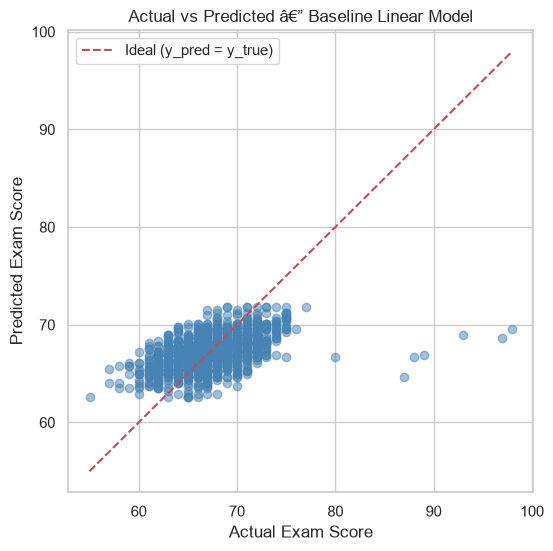

In [19]:
# Actual vs Predicted scatter â€” points on the dashed diagonal are perfect predictions.
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_base, alpha=0.5, color='steelblue')
lims = [min(y_test.min(), y_pred_base.min()), max(y_test.max(), y_pred_base.max())]
plt.plot(lims, lims, 'r--', label='Ideal (y_pred = y_true)')
plt.title('Actual vs Predicted â€” Baseline Linear Model')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.legend()
plt.show()

## 7. Bonus 1 â€” Polynomial Regression

The scatter already hints the relationship might be slightly *curved*. We replace the single
feature with polynomial expansions (**degree 2 and degree 3**) inside a pipeline, retrain,
evaluate on the same test split and compare against the linear baseline.
Degrees much higher would risk overfitting, so we stop at 3.

In [20]:
# Pipeline: expand Hours_Studied to (1, x, x^2) then fit linear regression.
poly2 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly2.fit(X_train, y_train)
y_pred2 = poly2.predict(X_test)
r2_2, mae_2, rmse_2 = evaluate(y_test, y_pred2)

print(f'Polynomial deg 2  R2  = {r2_2:.4f}')
print(f'Polynomial deg 2  MAE = {mae_2:.4f}')
print(f'Polynomial deg 2  RMSE= {rmse_2:.4f}')

Polynomial deg 2  R2  = 0.2332
Polynomial deg 2  MAE = 2.4434
Polynomial deg 2  RMSE= 3.2923


In [21]:
# Pipeline: expand Hours_Studied to (1, x, x^2, x^3) then fit linear regression.
poly3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly3.fit(X_train, y_train)
y_pred3 = poly3.predict(X_test)
r2_3, mae_3, rmse_3 = evaluate(y_test, y_pred3)

print(f'Polynomial deg 3  R2  = {r2_3:.4f}')
print(f'Polynomial deg 3  MAE = {mae_3:.4f}')
print(f'Polynomial deg 3  RMSE= {rmse_3:.4f}')

Polynomial deg 3  R2  = 0.2330
Polynomial deg 3  MAE = 2.4440
Polynomial deg 3  RMSE= 3.2926


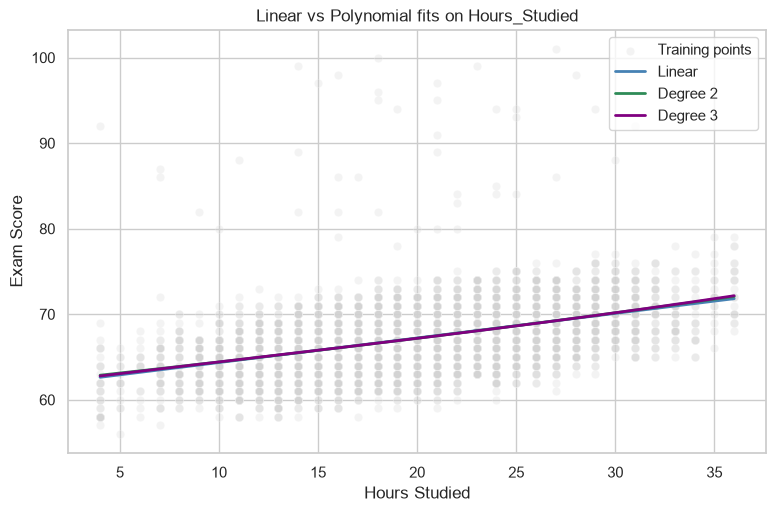

In [22]:
# Visual comparison: all three curves fitted on the training data.
xs_grid = np.linspace(X_train['Hours_Studied'].min(), X_train['Hours_Studied'].max(), 300)
grid = pd.DataFrame({'Hours_Studied': xs_grid})

plt.figure(figsize=(9, 5.5))
sns.scatterplot(x=X_train['Hours_Studied'], y=y_train, alpha=0.25, color='lightgray',
                label='Training points')
plt.plot(xs_grid, model_base.predict(grid), color='steelblue', linewidth=2, label='Linear')
plt.plot(xs_grid, poly2.predict(grid), color='seagreen', linewidth=2, label='Degree 2')
plt.plot(xs_grid, poly3.predict(grid), color='purple',   linewidth=2, label='Degree 3')
plt.title('Linear vs Polynomial fits on Hours_Studied')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

In [23]:
# Summary table: linear baseline vs polynomial degrees 2 and 3.
comp_poly = pd.DataFrame({
    'Model': ['Linear (1 feature)', 'Polynomial degree 2', 'Polynomial degree 3'],
    'R2':    [r2_base, r2_2, r2_3],
    'MAE':   [mae_base, mae_2, mae_3],
    'RMSE':  [rmse_base, rmse_2, rmse_3],
})
print(comp_poly.to_string(index=False))

              Model       R2      MAE     RMSE
 Linear (1 feature) 0.232372 2.446029 3.294007
Polynomial degree 2 0.233174 2.443418 3.292285
Polynomial degree 3 0.233022 2.444040 3.292611


## 8. Bonus 2 â€” Multi-feature Model

One feature can only explain so much. Here we add the four other **numerical** candidates named in
the brief â€” `Sleep_Hours`, `Attendance`, `Tutoring_Sessions` and `Previous_Scores` â€” alongside
`Hours_Studied`, and fit a fresh linear regression. We reuse the **same 80/20 split
(random_state=42)** so the comparison stays apples-to-apples.

In [24]:
# Multi-feature matrix: 5 numerical predictors.
multi_feats = ['Hours_Studied', 'Sleep_Hours', 'Attendance', 'Tutoring_Sessions', 'Previous_Scores']
X_multi = df[multi_feats]

# Identical split setting as the baseline, but on the wider feature set.
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_multi, y, test_size=0.2,
                                                        random_state=42)

# Fit a fresh linear regression on the 5 features.
model_multi = LinearRegression()
model_multi.fit(Xm_train, ym_train)
ym_pred = model_multi.predict(Xm_test)

# Evaluate on the test set.
r2_multi, mae_multi, rmse_multi = evaluate(ym_test, ym_pred)

print(f'Multi-feature  R2  = {r2_multi:.4f}')
print(f'Multi-feature  MAE = {mae_multi:.4f}')
print(f'Multi-feature  RMSE= {rmse_multi:.4f}')

# Show the learned coefficients â€” sign/magnitude show which features matter most.
coef_table = pd.Series(model_multi.coef_, index=multi_feats, name='coefficient')
print('\nFeature coefficients:')
print(coef_table)

Multi-feature  R2  = 0.6392
Multi-feature  MAE = 1.2821
Multi-feature  RMSE= 2.2584

Feature coefficients:
Hours_Studied        0.291558
Sleep_Hours         -0.034414
Attendance           0.198451
Tutoring_Sessions    0.561421
Previous_Scores      0.048475
Name: coefficient, dtype: float64


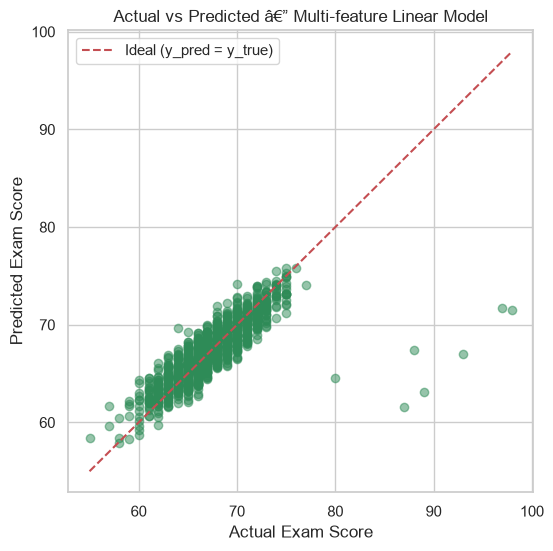

In [25]:
# Actual vs Predicted for the multi-feature model (bonus visual check).
plt.figure(figsize=(6, 6))
plt.scatter(ym_test, ym_pred, alpha=0.5, color='seagreen')
lims = [min(ym_test.min(), ym_pred.min()), max(ym_test.max(), ym_pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal (y_pred = y_true)')
plt.title('Actual vs Predicted â€” Multi-feature Linear Model')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.legend()
plt.show()

## 9. Feature Combination Experiments

So far we tested single-feature baselines and one fixed 5-feature set. But the *choice* of features
drives performance as much as the model does. In this section we run a small **feature-selection
experiment**: seven candidate feature combinations, all trained with the **same 80/20 split
(random_state=42)** and evaluated with RÂ², MAE and RMSE.

- **Option 1** (`Hours_Studied` only) is the baseline already fitted in Section 6 â€” we **reuse** its
  metrics and do **not** retrain it.
- All categorical columns are **already encoded** in `df` (ordinal 0-2 / binary 0-1). The only
  exception is `Parental_Involvement`, which is **not among the 17 task columns**, so we load it
  from the raw CSV and encode it once â€” no existing column is re-encoded.

### 9.1 Add the one missing feature: `Parental_Involvement`

Options 4 and 6 use `Parental_Involvement`, but it wasn't among the 17 columns selected at load
time. We load it from the raw CSV and encode it with the same ordinal scheme used for the other
category columns (`Low=0, Medium=1, High=2`). Only this new column is encoded.

In [26]:
# Parental_Involvement is required by Options 4 and 6 but was excluded when loading the data,
# so pull it from the raw CSV and encode it here (Low/Medium/High -> 0/1/2).
raw_pi = pd.read_csv('StudentPerformanceFactors.csv', usecols=['Parental_Involvement'])
df['Parental_Involvement'] = raw_pi['Parental_Involvement'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Sanity check: every row has a value and nothing came out missing.
print('Parental_Involvement value counts:')
print(df['Parental_Involvement'].value_counts().sort_index())
print('Missing values:', int(df['Parental_Involvement'].isna().sum()))

Parental_Involvement value counts:
Parental_Involvement
0    1337
1    3362
2    1908
Name: count, dtype: int64
Missing values: 0


### 9.2 Train the six new combinations (Option 1 is reused, not retrained)

Each remaining option gets a **fresh `LinearRegression` trained on the identical 80/20 split**
(`random_state=42`). Option 1's numbers are simply carried over from the baseline model.

In [27]:
# Define the six NEW feature combinations to try (Option 1 already exists as the baseline).
options = {
    'Option 2': ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions'],
    'Option 3': ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Sleep_Hours',
                 'Physical_Activity', 'Tutoring_Sessions'],
    'Option 4': ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions',
                 'Motivation_Level', 'Parental_Involvement'],
    'Option 5': ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Internet_Access',
                 'School_Type', 'Gender'],
    'Option 6': ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions',
                 'Sleep_Hours', 'Motivation_Level', 'Parental_Involvement', 'Internet_Access'],
    'Option 7': [c for c in df.columns if c != 'Exam_Score'],  # every column except the target
}

# Loop over options: same split seed every time, a fresh LinearRegression per option.
comb_results = {}

# Track the single best-scoring model so the Gradio demo can reuse it later
# WITHOUT retraining (this must be the highest-R2 option).
best_r2 = -1.0
best_model = None
best_features = None

for name, feats in options.items():
    Xo = df[feats]
    Xo_train, Xo_test, yo_train, yo_test = train_test_split(Xo, y, test_size=0.2,
                                                            random_state=42)
    mo = LinearRegression()
    mo.fit(Xo_train, yo_train)
    yo_pred = mo.predict(Xo_test)
    r2_o, mae_o, rmse_o = evaluate(yo_test, yo_pred)
    comb_results[name] = (r2_o, mae_o, rmse_o)
    # Remember the model with the highest test R2 so far.
    if r2_o > best_r2:
        best_r2, best_model, best_features = r2_o, mo, feats
    print(f'{name} -> R2={r2_o:.4f}  MAE={mae_o:.4f}  RMSE={rmse_o:.4f}')

# The best option (and its already-fitted model) for the interactive demo later.
best_option = max(comb_results, key=lambda k: comb_results[k][0])
print(f'\nBest option for the demo: {best_option}  (R2={comb_results[best_option][0]:.4f}, '
      f'{len(best_features)} features)')

Option 2 -> R2=0.6398  MAE=1.2804  RMSE=2.2566
Option 3 -> R2=0.6400  MAE=1.2730  RMSE=2.2558
Option 4 -> R2=0.6829  MAE=1.0997  RMSE=2.1171
Option 5 -> R2=0.6235  MAE=1.3508  RMSE=2.3070
Option 6 -> R2=0.6830  MAE=1.0910  RMSE=2.1169
Option 7 -> R2=0.7361  MAE=0.8023  RMSE=1.9313

Best option for the demo: Option 7  (R2=0.7361, 17 features)


### 9.3 Compare all seven options side by side + bar chart

We assemble a single clean table with all seven options (Option 1's row pulled from the baseline)
and then a bar chart shows the RÂ² ranking instantly.

In [28]:
# Single comparison table: Option 1 is REUSED (baseline), Options 2-7 freshly trained.
opt_labels = ['Option 1 (Hours_Studied only)',
              'Option 2 (Hours, Att, PrevScore, Tutoring)',
              'Option 3 (Hours, Att, PrevScore, Sleep, PhysAct, Tutoring)',
              'Option 4 (Hours, Att, PrevScore, Tutoring, Motivation, ParentalInv)',
              'Option 5 (Hours, Att, PrevScore, Internet, SchoolType, Gender)',
              'Option 6 (Hours, Att, PrevScore, Tutoring, Sleep, Motivation, ParentalInv, Internet)',
              'Option 7 (all columns except Exam_Score)']

comb_table = pd.DataFrame({
    'Option': opt_labels,
    'R2':   [r2_base] + [comb_results[k][0] for k in options],
    'MAE':  [mae_base] + [comb_results[k][1] for k in options],
    'RMSE': [rmse_base] + [comb_results[k][2] for k in options],
})
print(comb_table.to_string(index=False))

                                                                              Option       R2      MAE     RMSE
                                                       Option 1 (Hours_Studied only) 0.232372 2.446029 3.294007
                                          Option 2 (Hours, Att, PrevScore, Tutoring) 0.639751 1.280381 2.256577
                          Option 3 (Hours, Att, PrevScore, Sleep, PhysAct, Tutoring) 0.639991 1.273003 2.255827
                 Option 4 (Hours, Att, PrevScore, Tutoring, Motivation, ParentalInv) 0.682900 1.099700 2.117128
                      Option 5 (Hours, Att, PrevScore, Internet, SchoolType, Gender) 0.623478 1.350836 2.306982
Option 6 (Hours, Att, PrevScore, Tutoring, Sleep, Motivation, ParentalInv, Internet) 0.682967 1.091001 2.116906
                                            Option 7 (all columns except Exam_Score) 0.736132 0.802343 1.931269


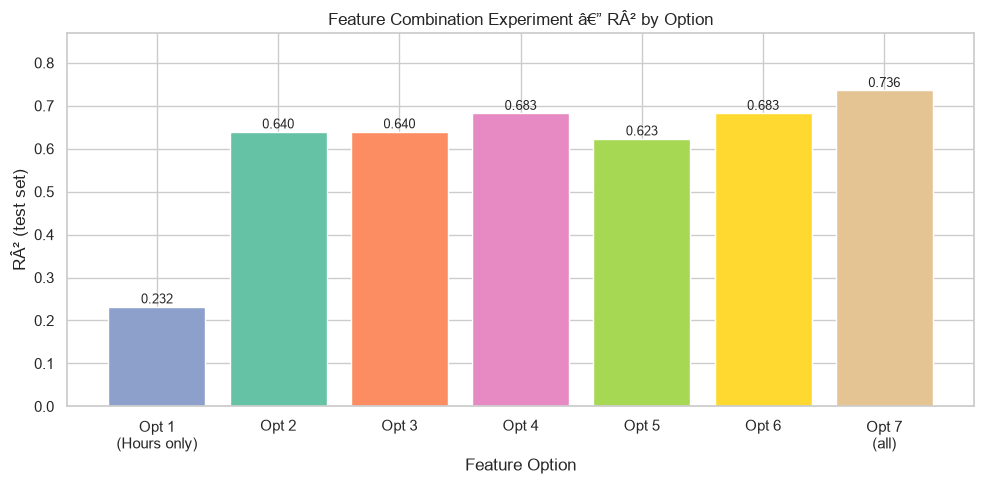

In [29]:
# Bar chart of R2 across all 7 options â€” which feature sets win is obvious at a glance.
r2_values = comb_table['R2'].tolist()
short_labels = ['Opt 1\n(Hours only)', 'Opt 2', 'Opt 3', 'Opt 4', 'Opt 5', 'Opt 6',
                'Opt 7\n(all)']

plt.figure(figsize=(10, 5))
bars = plt.bar(short_labels, r2_values,
               color=['#8da0cb', '#66c2a5', '#fc8d62', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494'])
# Label each bar with its R2 value for readability.
for bar, val in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + max(r2_values) * 0.01,
             f'{val:.3f}', ha='center', fontsize=9)
plt.title('Feature Combination Experiment â€” RÂ² by Option')
plt.xlabel('Feature Option')
plt.ylabel('RÂ² (test set)')
plt.ylim(0, max(r2_values) * 1.18)
plt.tight_layout()
plt.show()

### 9.4 Experiment summary

**Best option â€” Option 7 (all columns except `Exam_Score`)** wins on every metric: RÂ² = 0.736 vs
0.640 for the best 5-feature model, with MAE dropping from 1.28 to 0.80 and RMSE from 2.26 to 1.93.

**Categorical features that helped:** `Motivation_Level` and `Parental_Involvement` are the
standouts â€” comparing Option 4 with Option 2 (same features, plus these two) lifts RÂ² from 0.640 to
0.683, and pushing all categories into the model takes Option 7 to 0.736.

**Categorical features that added noise / little value:** `School_Type`, `Gender`,
`Internet_Access` and `Sleep_Hours` contributed almost nothing useful. Option 5 (RÂ² = 0.623) actually
scored slightly *below* Option 2 despite using six features, and Option 6 gained only ~0.0001 over
Option 4 from adding `Sleep_Hours` + `Internet_Access`.

## 10. Final Comparison Table

All four models, evaluated on the same 20% test split and the same 80/20 split (random_state=42),
side by side: **RÂ²** (higher = better), **MAE** and **RMSE** (both lower = better).

In [30]:
# One clean table comparing every model from this task.
final = pd.DataFrame({
    'Model': ['Linear (1 feature)', 'Polynomial degree 2', 'Polynomial degree 3',
              'Linear (multi-feature)'],
    'Features': ['Hours_Studied', 'Hours_Studied', 'Hours_Studied',
                 'Hours_Studied, Sleep_Hours, Attendance, Tutoring_Sessions, Previous_Scores'],
    'R2':   [r2_base, r2_2, r2_3, r2_multi],
    'MAE':  [mae_base, mae_2, mae_3, mae_multi],
    'RMSE': [rmse_base, rmse_2, rmse_3, rmse_multi],
})
print(final.to_string(index=False))

                 Model                                                                   Features       R2      MAE     RMSE
    Linear (1 feature)                                                              Hours_Studied 0.232372 2.446029 3.294007
   Polynomial degree 2                                                              Hours_Studied 0.233174 2.443418 3.292285
   Polynomial degree 3                                                              Hours_Studied 0.233022 2.444040 3.292611
Linear (multi-feature) Hours_Studied, Sleep_Hours, Attendance, Tutoring_Sessions, Previous_Scores 0.639155 1.282149 2.258445


## 11. Conclusion

**Best model â€” the multi-feature linear models.** Expanding past the single-`Hours_Studied`
baseline (RÂ² = 0.232) to five features raises RÂ² to 0.639, and the feature-combination experiment
shows that using **all columns except `Exam_Score`** delivers the best result overall:
RÂ² = **0.736**, MAE = **0.80**, RMSE = **1.93**. The polynomial degrees added essentially nothing
on top of the linear baseline (RÂ² â‰ˆ 0.233), so `Hours_Studied`'s effect is essentially linear here.

**Which features mattered most:** `Tutoring_Sessions` and `Hours_Studied` are the strongest numeric
drivers, with `Attendance` also contributing. Among categorical features, `Motivation_Level` and
`Parental_Involvement` mattered most (together they add ~0.04 to RÂ²). `Sleep_Hours`, `School_Type`,
`Gender` and `Internet_Access` added the least.

**One thing that could improve the model further:** add interaction and non-linear terms (e.g.
`Hours_Studied Ã— Attendance`, or a gradient-boosted forest / ridge with all features) to capture the
effects a linear model misses â€” even the best model still explains only ~74% of score variance.

## 12. Interactive Demo with Gradio

We turn the **best model into a small web app** so anyone can predict an exam score from the inputs
without touching the code.

**Which model is chosen and why:** the Feature Combination Experiments showed **Option 7**
(every feature except `Exam_Score`) had the **highest RÂ² = 0.736** on the test set, so that is the
model we wrap in the demo. It needs all **17 input features** â€” 6 numerical sliders and 11
categorical dropdowns â€” and uses the model **already trained** in this notebook (nothing is
retrained).

In [ ]:
# Install Gradio (quietly) â€” the exact command required by the task brief.
!pip install gradio -q

# Robust fallback for shells where `pip` is not on PATH (e.g. some Windows setups).
import sys
!{sys.executable} -m pip install gradio -q

In [ ]:
# Demo setup: imports, the reused Option 7 model, and the categorical encode maps.
import gradio as gr
import numpy as np

# The already-fitted Option 7 model and its feature list (reused directly, nothing retrained).
model = best_model
features = list(best_features)

# Human-readable choices for the categorical (ordinal / binary) features that were encoded.
# (Six numeric features stay as sliders and are passed through unchanged.)
ny_choices = ['Yes', 'No']
gender_choices = ['Male', 'Female']
school_choices = ['Public', 'Private']
low_med_high = ['Low', 'Medium', 'High']

# Encode each dropdown selection back to the same integer the model was trained on.
encode_maps = {
    'Motivation_Level':          dict(Low=0, Medium=1, High=2),
    'Internet_Access':           dict(Yes=1, No=0),
    'Family_Income':             dict(Low=0, Medium=1, High=2),
    'Teacher_Quality':           dict(Low=0, Medium=1, High=2),
    'School_Type':               dict(Public=1, Private=0),
    'Peer_Influence':            dict(Negative=0, Neutral=1, Positive=2),
    'Learning_Disabilities':     dict(Yes=1, No=0),
    'Parental_Education_Level':  dict({'High School': 0, 'College': 1, 'Postgraduate': 2}),
    'Distance_from_Home':        dict(Near=0, Moderate=1, Far=2),
    'Gender':                    dict(Male=1, Female=0),
    'Parental_Involvement':      dict(Low=0, Medium=1, High=2),
}

# The prediction function: one positional parameter per feature, in the EXACT order the
# Option 7 model was trained on (Gradio calls fn positionally, so order must match `inputs`).
def predict_score(hours_studied, attendance, sleep_hours, previous_scores, motivation_level,
                  internet_access, tutoring_sessions, family_income, teacher_quality,
                  school_type, peer_influence, physical_activity, learning_disabilities,
                  parental_education_level, distance_from_home, gender, parental_involvement):
    # Collect every value in training order, encoding categorical dropdowns via the maps above.
    row = [
        hours_studied, attendance, sleep_hours, previous_scores,
        encode_maps['Motivation_Level'][motivation_level],
        encode_maps['Internet_Access'][internet_access],
        tutoring_sessions,
        encode_maps['Family_Income'][family_income],
        encode_maps['Teacher_Quality'][teacher_quality],
        encode_maps['School_Type'][school_type],
        encode_maps['Peer_Influence'][peer_influence],
        physical_activity,
        encode_maps['Learning_Disabilities'][learning_disabilities],
        encode_maps['Parental_Education_Level'][parental_education_level],
        encode_maps['Distance_from_Home'][distance_from_home],
        encode_maps['Gender'][gender],
        encode_maps['Parental_Involvement'][parental_involvement],
    ]
    # Model predicts 1D -> scalar; clip to the dataset's 0-100 scale for a sensible answer.
    return float(np.clip(model.predict(np.array([row]))[0], 0, 100))

In [ ]:
# Build the Demo interface with one input per feature, in the exact training order.
inputs = []
for f in features:
    if f == 'Hours_Studied':
        inputs.append(gr.Slider(1, 44, value=20, step=1, label='Hours_Studied'))
    elif f == 'Attendance':
        inputs.append(gr.Slider(60, 100, value=80, step=1, label='Attendance'))
    elif f == 'Sleep_Hours':
        inputs.append(gr.Slider(4, 10, value=7, step=1, label='Sleep_Hours'))
    elif f == 'Previous_Scores':
        inputs.append(gr.Slider(50, 100, value=75, step=1, label='Previous_Scores'))
    elif f == 'Tutoring_Sessions':
        inputs.append(gr.Slider(0, 8, value=1, step=1, label='Tutoring_Sessions'))
    elif f == 'Physical_Activity':
        inputs.append(gr.Slider(0, 6, value=3, step=1, label='Physical_Activity'))
    elif f == 'Motivation_Level':
        inputs.append(gr.Dropdown(low_med_high, value='Medium', label='Motivation_Level'))
    elif f == 'Internet_Access':
        inputs.append(gr.Dropdown(ny_choices, value='Yes', label='Internet_Access'))
    elif f == 'Family_Income':
        inputs.append(gr.Dropdown(low_med_high, value='Medium', label='Family_Income'))
    elif f == 'Teacher_Quality':
        inputs.append(gr.Dropdown(low_med_high, value='Medium', label='Teacher_Quality'))
    elif f == 'School_Type':
        inputs.append(gr.Dropdown(school_choices, value='Public', label='School_Type'))
    elif f == 'Peer_Influence':
        inputs.append(gr.Dropdown(['Negative', 'Neutral', 'Positive'], value='Neutral',
                                  label='Peer_Influence'))
    elif f == 'Learning_Disabilities':
        inputs.append(gr.Dropdown(ny_choices, value='No', label='Learning_Disabilities'))
    elif f == 'Parental_Education_Level':
        inputs.append(gr.Dropdown(['High School', 'College', 'Postgraduate'], value='College',
                                  label='Parental_Education_Level'))
    elif f == 'Distance_from_Home':
        inputs.append(gr.Dropdown(['Near', 'Moderate', 'Far'], value='Near',
                                  label='Distance_from_Home'))
    elif f == 'Gender':
        inputs.append(gr.Dropdown(gender_choices, value='Male', label='Gender'))
    elif f == 'Parental_Involvement':
        inputs.append(gr.Dropdown(low_med_high, value='Medium', label='Parental_Involvement'))

# A single numeric output that shows the predicted exam score rounded to 1 decimal.
output = gr.Number(label='Predicted Exam Score', precision=1)

# Assemble the app and launch it inside the notebook (share=False -> local browser).
demo = gr.Interface(fn=predict_score, inputs=inputs, outputs=output,
                    title='Student Exam Score Predictor',
                    description='Enter student characteristics; the best (Option 7) model predicts '
                                'their exam score.')
demo.launch(share=False, inbrowser=False)